In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os
from IPython.display import clear_output

In [3]:
results_base = "structured_results"
llama_8b = pd.read_csv(os.path.join(results_base, "Macko SPMV - Llama3-8B.csv"))
llama_70b = pd.read_csv(os.path.join(results_base, "Macko SPMV - Llama3-70B.csv"))



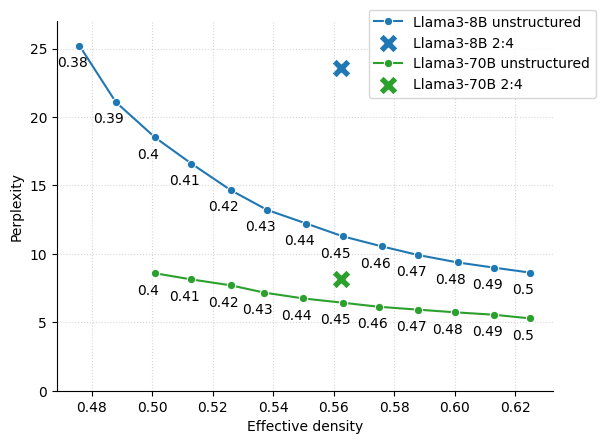

In [53]:
paper_path = "../../macko_spmv_paper"

def draw(df, tag, color):
    unstructured_df = df.query("Method=='Wanda unstructured'")
    sns.lineplot(
        unstructured_df,
        x="Effective density",
        y="Perplexity", label=tag+" unstructured", color=color,
        marker='o'
        )
    
    for _, row in unstructured_df.iterrows():
        plt.annotate(
            row["Density"],
            (row["Effective density"], row["Perplexity"]),
            textcoords="offset points",
            xytext=(-5,-15),
            ha='center'
        )


    structured_df = df.query("Method=='Wanda 2:4'")
    sns.scatterplot(
        structured_df,
        x="Effective density",
        y="Perplexity", label=tag+ " 2:4", color=color, 
        marker="X", s=200
    )
    pass

draw(llama_8b, "Llama3-8B", "tab:blue")
draw(llama_70b, "Llama3-70B", "tab:green")
plt.ylim(0, 27)
plt.grid(linestyle=":", alpha=0.5)
plt.legend(bbox_to_anchor=(1.1, 1.05))

paper_graph_path = os.path.join(paper_path, "paper/structured_pruning.pdf")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(paper_graph_path, bbox_inches='tight')